<a href="https://colab.research.google.com/github/25wh1a0548-collab/NASSCOM/blob/main/u3_python_part2_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style='whitegrid')
np.random.seed(42)
print('Setup complete. NumPy', np.__version__, '| Pandas', pd.__version__)

Setup complete. NumPy 2.0.2 | Pandas 2.2.2


In [6]:
a = np.arange(6).reshape(2, 3)
print('Array a:\n', a)
print('shape :', a.shape)
print('ndim  :', a.ndim)
print('dtype :', a.dtype)

Array a:
 [[0 1 2]
 [3 4 5]]
shape : (2, 3)
ndim  : 2
dtype : int64


In [7]:
print('Column index 1 :', a[:, 1])
print('Row index 0    :', a[0, :])
print('Elements > 2   :', a[a > 2])

Column index 1 : [1 4]
Row index 0    : [0 1 2]
Elements > 2   : [3 4 5]


In [8]:
row = np.array([10, 20, 30])
print('a + row (row added to every row of a):\n', a + row)

a + row (row added to every row of a):
 [[10 21 32]
 [13 24 35]]


In [9]:
b = np.ones((3, 2), dtype=int)
print('Matrix product a @ b:\n', a @ b)
print('Column-wise sum  (axis=0):', a.sum(axis=0))
print('Row-wise sum     (axis=1):', a.sum(axis=1))
print('Row-wise mean    (axis=1):', a.mean(axis=1))
print('Index of max per column  :', a.argmax(axis=0))

Matrix product a @ b:
 [[ 3  3]
 [12 12]]
Column-wise sum  (axis=0): [3 5 7]
Row-wise sum     (axis=1): [ 3 12]
Row-wise mean    (axis=1): [1. 4.]
Index of max per column  : [1 1 1]


In [10]:
import numpy as np

# Given data
M = np.arange(1, 13).reshape(3, 4)   # shape (3, 4)
N = np.arange(1, 9).reshape(4, 2)    # shape (4, 2)

print("M:\n", M)
print("N:\n", N)

# 1. Matrix product M @ N
matrix_product = M @ N
print("\nMatrix Product (M @ N):\n", matrix_product)

# 2. Column-wise sum (axis=0) and row-wise mean (axis=1) of M
column_sum = M.sum(axis=0)
row_mean = M.mean(axis=1)

print("\nColumn-wise Sum:", column_sum)
print("Row-wise Mean:", row_mean)

# 3. Index of the max value in each row of M
max_indices = M.argmax(axis=1)
print("\nIndex of max value in each row:", max_indices)

M:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
N:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]

Matrix Product (M @ N):
 [[ 50  60]
 [114 140]
 [178 220]]

Column-wise Sum: [15 18 21 24]
Row-wise Mean: [ 2.5  6.5 10.5]

Index of max value in each row: [3 3 3]


In [12]:
import pandas as pd
import seaborn as sns
# 🔹 2A. LOAD & INSPECT
df = sns.load_dataset('titanic')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
df.info()
print("\nSummary Statistics:")
print(df.describe())
# 🔹 2B. HANDLE MISSING VALUES
print("Missing values per column:")
print(df.isna().sum().sort_values(ascending=False).head())
df["age"] = df["age"].fillna(df["age"].median())
print("\nMissing ages after fillna:", df["age"].isna().sum())

# 🔹 2C. GROUP BY A CATEGORY (split -> apply -> combine)
print("\nSurvival rate by class:")
print(df.groupby("class", observed=True)["survived"].mean())
print("\nSurvival rate by class and sex:")
print(df.groupby(["class", "sex"], observed=True)["survived"].mean())

Shape: (891, 15)

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       ------

In [13]:
import seaborn as sns

lab = sns.load_dataset('titanic')

# 1. Count missing values in 'embarked'
print("Missing values in 'embarked':", lab['embarked'].isna().sum())

# 2. Fill missing 'embarked' with the mode
lab['embarked'] = lab['embarked'].fillna(lab['embarked'].mode()[0])

# Verify there are no missing values
print("Missing values after fill:", lab['embarked'].isna().sum())

# 3. Mean fare grouped by 'sex'
print("\nMean fare by sex:")
print(lab.groupby('sex', observed=True)['fare'].mean())

Missing values in 'embarked': 2
Missing values after fill: 0

Mean fare by sex:
sex
female    44.479818
male      25.523893
Name: fare, dtype: float64


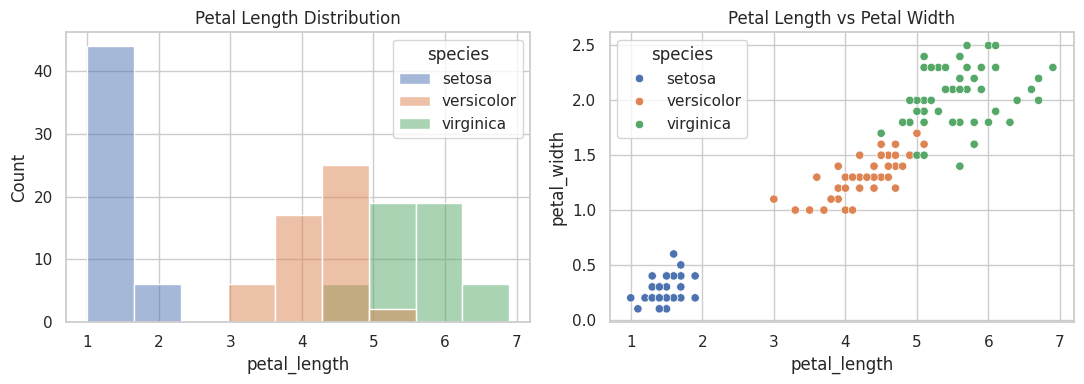

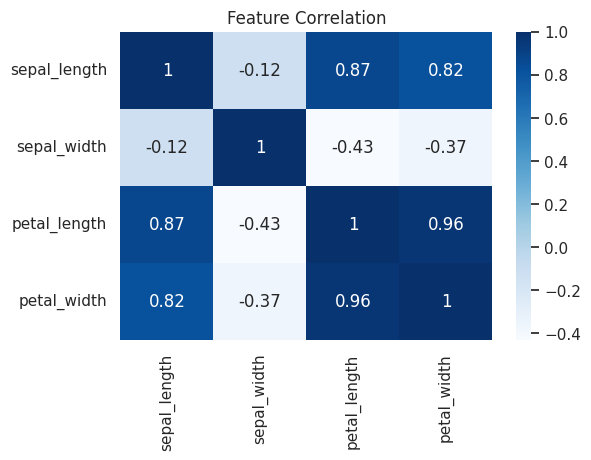

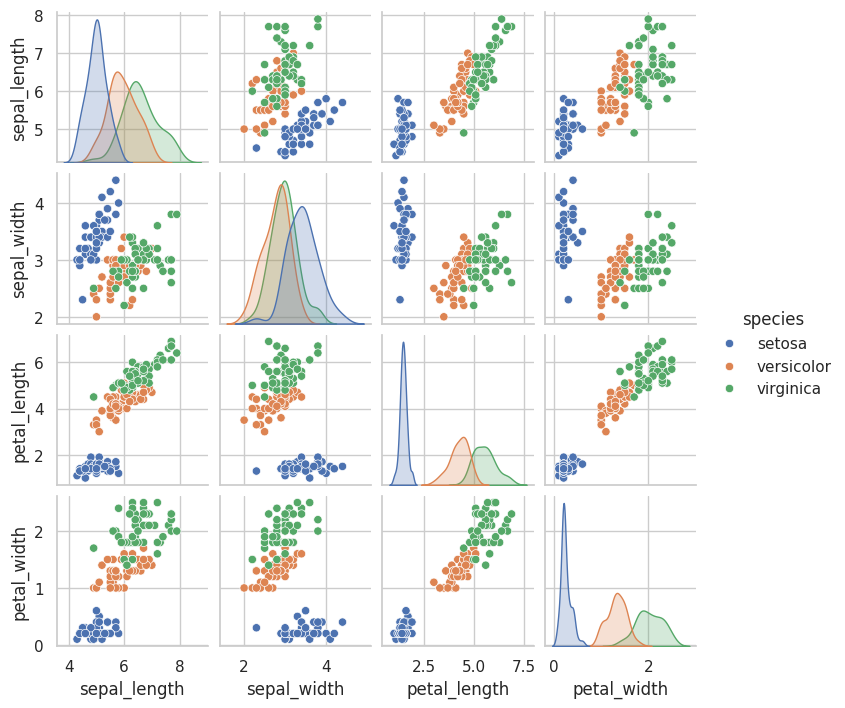

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
iris = sns.load_dataset('iris')

# 3A. SUBPLOT COMPARISON

# Create a figure with 1 row and 2 columns of plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram showing petal length distribution for each species
sns.histplot(data=iris, x='petal_length', hue='species', ax=axes[0])
axes[0].set_title('Petal Length Distribution')

# Scatter plot showing relationship between petal length and petal width
sns.scatterplot(data=iris,
                x='petal_length',
                y='petal_width',
                hue='species',
                ax=axes[1])
axes[1].set_title('Petal Length vs Petal Width')

# Adjust spacing between plots and display them
plt.tight_layout()
plt.show()

# 3B. CORRELATION HEATMAP
# Create a new figure
plt.figure(figsize=(6, 4))
sns.heatmap(
    iris.drop(columns='species').corr(),
    annot=True,
    cmap='Blues'
)

# Add title and display the heatmap
plt.title('Feature Correlation')
plt.show()

# 3C. PAIRPLOT
sns.pairplot(iris, hue='species', height=1.8)
plt.show()

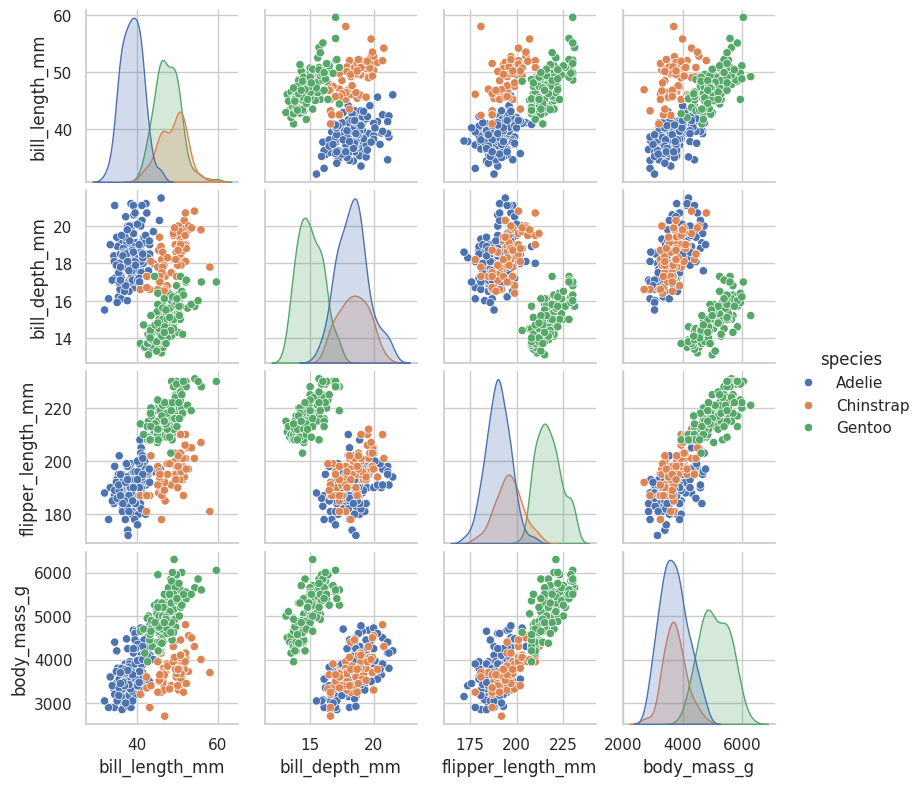

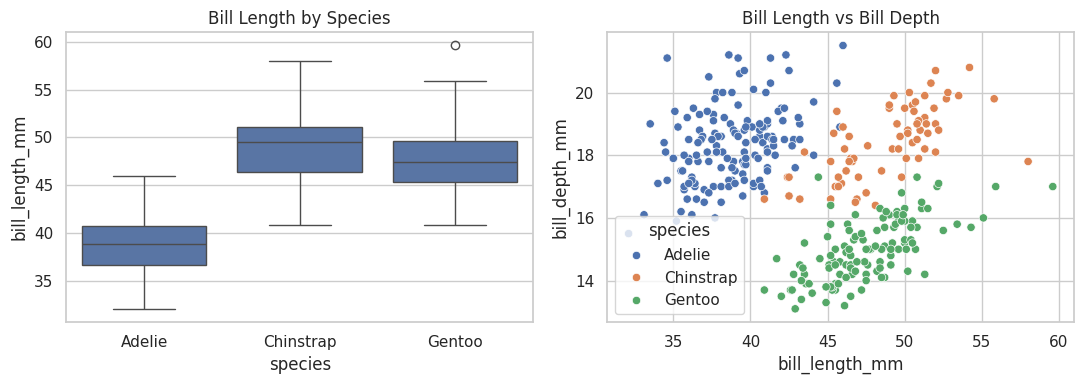

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
pen = sns.load_dataset('penguins')

# Remove missing values
pen = pen.dropna()

# Pairplot by species
sns.pairplot(pen, hue='species', height=2)
plt.show()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot
sns.boxplot(data=pen, x='species', y='bill_length_mm', ax=axes[0])
axes[0].set_title("Bill Length by Species")

# Scatter plot
sns.scatterplot(data=pen, x='bill_length_mm', y='bill_depth_mm',
                hue='species', ax=axes[1])
axes[1].set_title("Bill Length vs Bill Depth")

plt.tight_layout()
plt.show()

In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 4A. Load and Split the Data
X, y = load_iris(return_X_y=True)
print("Features X:", X.shape, "| Target y:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape[0], "samples | Test:", X_test.shape[0], "samples")

# 4B. Train and Evaluate Model

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

# 4C. Create and Use Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])
pipe.fit(X_train, y_train)
print("Pipeline Accuracy:", round(pipe.score(X_test, y_test), 3))

Features X: (150, 4) | Target y: (150,)
Train: 120 samples | Test: 30 samples
Accuracy: 0.9
Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]
Pipeline Accuracy: 0.933


In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load dataset
Xb, yb = load_breast_cancer(return_X_y=True)
print("Breast cancer data:", Xb.shape)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=42
)

# Create pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])

# Train and evaluate
pipe.fit(X_train, y_train)
print("Test Accuracy:", round(pipe.score(X_test, y_test), 3))

Breast cancer data: (569, 30)
Test Accuracy: 0.974


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = sns.load_dataset('titanic')

# Clean the data
data = data[['survived', 'pclass', 'sex', 'age', 'fare']].copy()
data['age'] = data['age'].fillna(data['age'].median())
data['sex'] = np.where(data['sex'] == 'male', 0, 1)
data = data.dropna()

# Split features and target
X = data.drop(columns='survived').values
y = data['survived'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train and evaluate the model
model = RandomForestClassifier(random_state=42)
model.fit(X_tr, y_tr)

acc = accuracy_score(y_te, model.predict(X_te))
print("End-to-end Titanic Survival Accuracy:", round(acc, 3))

# Plot feature importance
importances = pd.Series(
    model.feature_importances_,
    index=data.drop(columns='survived').columns
)

importances.sort_values().plot.barh(title="Feature Importance")
plt.tight_layout()
plt.show()

End-to-end Titanic Survival Accuracy: 0.793


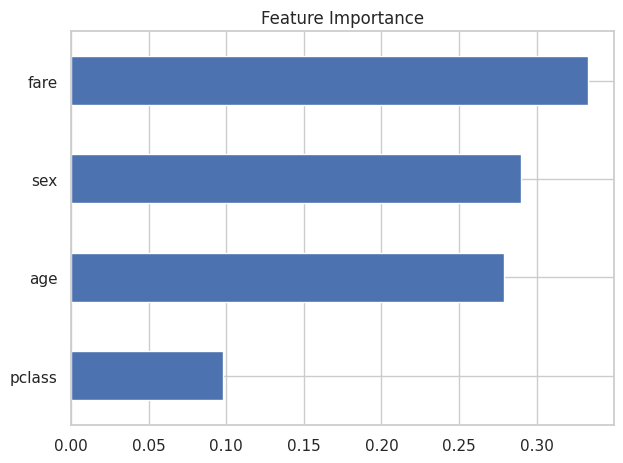

In [19]:

# 🔹 5. END-TO-END MINI WORKFLOW
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = sns.load_dataset('titanic')

data = data[['survived', 'pclass', 'sex', 'age', 'fare']].copy()
data['age'] = data['age'].fillna(data['age'].median())
data['sex'] = np.where(data['sex'] == 'male', 0, 1)
data = data.dropna()

X = data.drop(columns='survived').values
y = data['survived'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_tr, y_tr)

acc = accuracy_score(y_te, model.predict(X_te))
print("End-to-end Titanic Survival Accuracy:", round(acc, 3))

importances = pd.Series(
    model.feature_importances_,
    index=data.drop(columns='survived').columns
)

importances.sort_values().plot.barh(title="Feature Importance")
plt.tight_layout()
plt.show()

Test Accuracy: 1.0


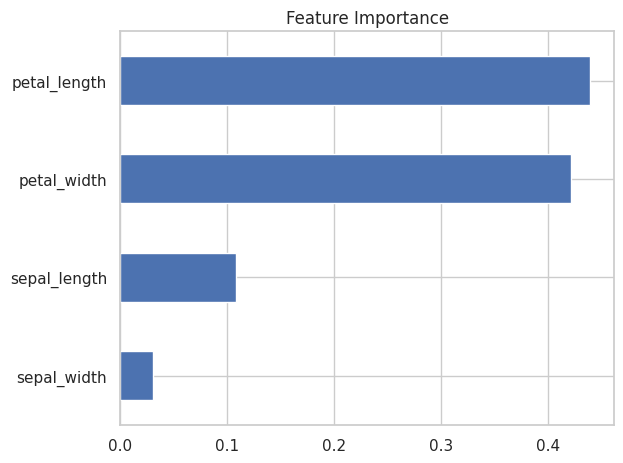

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = sns.load_dataset('iris')

# Clean / Encode
X = data.drop(columns='species')
y = data['species'].astype('category').cat.codes

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Output
pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)
print("Test Accuracy:", round(acc, 3))

# Feature Importance Diagram
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importances.sort_values().plot.barh(title="Feature Importance")
plt.tight_layout()
plt.show()